# Data Cleaning & Preparation

*This notebook prepares the Google Play Store dataset for an Exploratory Data Analysis (EDA) that will identify which app categories are price-forgiving vs. price-sensitive, and whether a pricing tipping point exists. Every data cleaning, imputation, and dropping decision below is justified strictly with respect to preserving the integrity of this pricing and rating signal.*

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
from pyampute.exploration.mcar_statistical_tests import MCARTest
from scipy import stats

In [2]:
df = pd.read_csv("googleplaystore.csv", low_memory=False)

### 1. INSPECT DATA

#### 1.1) Check first few rows to understand the structure and what each column means.

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


#### 1.2) Check its shape understand entire dataset structure.

In [4]:
df.shape

(10841, 13)

#### 1.3) Get basic summary of the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


There are a lot of columns that are supposed to be numeric but aren't (*rating, size, installs, price, current ver?, and android ver?*).
Also *Last Updated* is of object dtype, instead of date time.

#### 1.4) Check summary statistics(added include="all" to see the columns that are supposed to be numeric).

In [6]:
df.describe(include="all")

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 1.5) Get column names. Alternatively can just use df.columns.

In [7]:
df.columns.to_list()

['App',
 'Category',
 'Rating',
 'Reviews',
 'Size',
 'Installs',
 'Type',
 'Price',
 'Content Rating',
 'Genres',
 'Last Updated',
 'Current Ver',
 'Android Ver']

#### 1.6) Get summary percentages of nulls per column to get the null population before we clean(drop/ impute) them.

In [8]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
missing_pct = df.isnull().mean() * 100
print(missing_pct)

App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64


**Null Ratings — Drop Decision:** An app without a `Rating` cannot be evaluated for price-forgiveness or price-sensitivity. It contributes no signal to our core EDA question and is therefore mathematically useless for this analysis. The ~13.5% missing rate is noted, but the decisive factor is not the percentage: a ratingless row carries zero analytical value for our specific objective. The missingness mechanism will be verified formally in Section 4.

### 2. Investigating Problems

#### 2.1) Checking the nulls

#### 2.1.1) Isolating the nulls into a separate dataframe.

In [10]:
df_null = df[df['Rating'].isna()]

#### 2.1.2) Inspect the first rows of the null dataframe.

In [11]:
df_null.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
23,Mcqueen Coloring pages,ART_AND_DESIGN,NaN,61,7.0M,"100,000+",Free,0,Everyone,Art & Design;Action & Adventure,"March 7, 2018",1.0.0,4.1 and up
113,Wrinkles and rejuvenation,BEAUTY,NaN,182,5.7M,"100,000+",Free,0,Everyone 10+,Beauty,"September 20, 2017",8.0,3.0 and up
123,Manicure - nail design,BEAUTY,NaN,119,3.7M,"50,000+",Free,0,Everyone,Beauty,"July 23, 2018",1.3,4.1 and up
126,Skin Care and Natural Beauty,BEAUTY,NaN,654,7.4M,"100,000+",Free,0,Teen,Beauty,"July 17, 2018",1.15,4.1 and up
129,"Secrets of beauty, youth and health",BEAUTY,NaN,77,2.9M,"10,000+",Free,0,Mature 17+,Beauty,"August 8, 2017",2.0,2.3 and up
130,Recipes and tips for losing weight,BEAUTY,NaN,35,3.1M,"10,000+",Free,0,Everyone 10+,Beauty,"December 11, 2017",2.0,3.0 and up
134,"Lady adviser (beauty, health)",BEAUTY,NaN,30,9.9M,"10,000+",Free,0,Mature 17+,Beauty,"January 24, 2018",3.0,3.0 and up
163,Anonymous caller detection,BOOKS_AND_REFERENCE,NaN,161,2.7M,"10,000+",Free,0,Everyone,Books & Reference,"July 13, 2018",1.0,2.3 and up
180,SH-02J Owner's Manual (Android 8.0),BOOKS_AND_REFERENCE,NaN,2,7.2M,"50,000+",Free,0,Everyone,Books & Reference,"June 15, 2018",3.0,6.0 and up
185,URBANO V 02 instruction manual,BOOKS_AND_REFERENCE,NaN,114,7.3M,"100,000+",Free,0,Everyone,Books & Reference,"August 7, 2015",1.1,5.1 and up


#### 2.2) Checking the duplicates.

#### 2.2.1) Get the sum for duplicates in the entire dataframe and separate columns.

In [12]:
def duplicate_summary(df):
    total_duplicate_rows = df.duplicated().sum()
    duplicate_values_per_column = df.apply(
        lambda col: col.duplicated(keep=False).sum()
    )

    print("Total duplicate rows:", total_duplicate_rows)
    print("\nDuplicate values per column:")
    print(duplicate_values_per_column)
    
duplicate_summary(df)

Total duplicate rows: 483

Duplicate values per column:
App                1979
Category          10840
Rating            10839
Reviews            5855
Size              10595
Installs          10839
Type              10839
Price             10787
Content Rating    10840
Genres            10817
Last Updated      10417
Current Ver        9030
Android Ver       10836
dtype: int64


#### 2.2.2) Get the duplicate population percentage of the entire dataset.

In [13]:
def check_duplicates(df):
    duplicate_pct = df.apply(lambda col: col.duplicated(keep=False).mean()) * 100
    total_duplicates = df.duplicated(keep=False).sum()
    
    print("Column duplicates percentage:")
    print(duplicate_pct)
    print("\nTotal duplicate rows:", total_duplicates)
    
    return #duplicate_pct, total_duplicates

check_duplicates(df)

Column duplicates percentage:
App               18.254774
Category          99.990776
Rating            99.981552
Reviews           54.007933
Size              97.730837
Installs          99.981552
Type              99.981552
Price             99.501891
Content Rating    99.990776
Genres            99.778618
Last Updated      96.088922
Current Ver       83.294899
Android Ver       99.953879
dtype: float64

Total duplicate rows: 893


#### 2.2.3) Get total duplicates per column. Analyze each column and determine the duplicate-ness of each.

In [14]:
def duplicate_per_column(df):
    for col in df:
        print(f"{col}: {df[col].duplicated().sum()}")

duplicate_per_column(df)

App: 1181
Category: 10807
Rating: 10800
Reviews: 4839
Size: 10379
Installs: 10819
Type: 10837
Price: 10748
Content Rating: 10834
Genres: 10721
Last Updated: 9463
Current Ver: 8008
Android Ver: 10807


##### CHECK APP COLUMN DUPLICATES

In [15]:
df[df.duplicated(subset='App', keep=False)].sort_values('App').head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up
3083,365Scores - Live Scores,SPORTS,4.6,666521,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up
5415,365Scores - Live Scores,SPORTS,4.6,666246,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up


#### 2.3) Checking inconsistent categorical values

#### 2.3.1) Check unique values per column. Ultimate re-usable function.

In [16]:
def unique_summary(df):
    for col in df.columns:
        print(f"\n{'-'*10}")
        print(f"Column: {col}")
        print(f"Total records: {len(df[col])}")
        print(f"Total unique: {df[col].nunique(dropna=False)}")
        print(f"Unique values:")
        print(df[col].unique())

unique_summary(df)


----------
Column: App
Total records: 10841
Total unique: 9660
Unique values:
['Photo Editor & Candy Camera & Grid & ScrapBook' 'Coloring book moana'
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps' ...
 'Parkinson Exercices FR' 'The SCP Foundation DB fr nn5n'
 'iHoroscope - 2018 Daily Horoscope & Astrology']

----------
Column: Category
Total records: 10841
Total unique: 34
Unique values:
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

----------
Column: Rating
Total records: 10841
Total unique: 41
Unique values:
[ 4.1  3.9  4.7  4.5  4.3  4.4  3.8  4.2  4.6  3.

In the dataframe, M stands for megabyte, k stands for kilobyte?
##### We check if there is kb

In [17]:
kb_sizes = df[df['Size'].str.contains(r'k$', case=False, na=False)]['Size'].unique()
print(kb_sizes)

['201k' '23k' '79k' '118k' '695k' '18k' '556k' '526k' '334k' '232k' '624k'
 '8.5k' '41k' '292k' '11k' '704k' '862k' '899k' '378k' '266k' '375k'
 '975k' '980k' '696k' '544k' '525k' '920k' '779k' '853k' '720k' '713k'
 '772k' '318k' '58k' '241k' '196k' '857k' '51k' '953k' '865k' '251k'
 '930k' '540k' '313k' '746k' '203k' '26k' '314k' '239k' '371k' '220k'
 '730k' '756k' '91k' '293k' '17k' '74k' '14k' '317k' '78k' '924k' '902k'
 '818k' '81k' '939k' '169k' '45k' '475k' '965k' '545k' '61k' '283k' '655k'
 '714k' '93k' '872k' '121k' '322k' '976k' '172k' '238k' '549k' '206k'
 '954k' '444k' '717k' '210k' '609k' '308k' '705k' '306k' '904k' '473k'
 '175k' '350k' '383k' '454k' '421k' '70k' '812k' '442k' '842k' '417k'
 '412k' '459k' '478k' '335k' '782k' '721k' '430k' '429k' '192k' '200k'
 '460k' '728k' '496k' '816k' '414k' '506k' '887k' '613k' '243k' '569k'
 '778k' '683k' '592k' '319k' '186k' '840k' '647k' '191k' '373k' '437k'
 '598k' '716k' '585k' '982k' '222k' '219k' '55k' '948k' '323k' '691k'
 '51

### problems regarding file size
1. The M and K
2. How do I standardize both since if I strip both 903k become 903, unless if we separate them?

### install problem
1. '+' sign after

#### price problems
1. $ sign and "Everyone"

#### 2.4) Extreme values

#### 2.4.1) Check extreme values of Reviews column ( the only numeric by default col).

In [18]:
df['Rating'].astype(float).sort_values(ascending=False).head(10)

10472    19.0
9511      5.0
10166     5.0
7895      5.0
5118      5.0
6953      5.0
5125      5.0
7896      5.0
5139      5.0
5145      5.0
Name: Rating, dtype: float64

10472 is a pain in the ass. Ratings should be 1-5. Will check that row.

In [19]:
df[df["Rating"] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


The row at index 10472 contains a `Rating` value of 19.0, an impossible entry on a 1–5 scale. Inspection confirms the row is a **row-shift error**: column values are misaligned, producing corrupt metrics across the board. A row with invalid metrics cannot be used to assess how ratings respond to pricing, so it is removed without imputation. All other rows with valid (or missing) ratings are preserved.

## Summary of Problems

- **Rating column** — ~13.5% missing values; also contains an invalid outlier value (19), impossible on a 1–5 scale
- **Reviews column** — stored as text; at least one record uses shorthand notation (`'3.0M'`) mixed in with plain integer values, so it cannot be directly converted to numeric
- **Size column** — inconsistent units, mixing `'M'` (megabytes) and `'k'` (kilobytes) in the same column, plus non-numeric `'Varies with device'` entries. Removing both by default would represent the data wrong. Search for workarounds we can do to standardize them without separating them to individual columns.
- **Installs column** — stored as text with a trailing `'+'` and comma thousands separators, preventing numeric conversion. The dilemma with removing the '+' is we might underestimate the value of the data. But keeping it hinders us from numerical analysis.
- **Price column** — stored as text with a leading `'$'` sign, preventing numeric conversion
- **Duplicate App records** — the same app name appears multiple times; some are legitimate re-scrapes at different review counts, others may be true duplicates, requiring manual review rather than automatic dropping
- **Incorrect data types** — `Size`, `Installs`, `Price`, and `Reviews` are stored as object/string dtype despite representing numeric quantities. Meanwhile `Last Updated` is supposed to be date time.

### 3. CLEANING PIPELINE

#### 3.1) Remove that one problematic record(10472), while keeping the rest of the nulls.

In [20]:
df = df[(df["Rating"] <= 5) | (df["Rating"].isna())].copy()

In [21]:
df.shape

(10840, 13)

#### 3.2) Fix all wrong dtypes. (Size, Reviews, Installs, Price, Last Updated)

#### 3.2.1) Fixing size. We convert k to mb ( divide by 1024) to get one standard value.

In [22]:
def clean_size(x):
    if pd.isna(x) or x == 'Varies with device':
        return np.nan
    if x.endswith('M'):
        return float(x[:-1])
    if x.endswith('k'):
        return float(x[:-1]) / 1024
    return np.nan

df['Size_MB'] = df['Size'].apply(clean_size)
df.drop(columns='Size', inplace=True)

In [23]:
# percentage of nulls vs total
null_size = df['Size_MB'].isnull().sum()
total_size = df['Size_MB'].count()
null_size_pct = df['Size_MB'].isnull().mean() * 100

print(f"{null_size} is the total null records.")
print(f"{null_size_pct:.2f}% is the total null percentage.")
print(f"{total_size} is the total non-null Size_MB records.")

1695 is the total null records.
15.64% is the total null percentage.
9145 is the total non-null Size_MB records.


#### 3.2.2) Fixing Reviews — Removing the `3.0M` Shorthand Record

One record stores its review count as the string `'3.0M'` (shorthand for ~3 million), which prevents numeric conversion. Accurate review counts are critical: before we can trust that a premium-priced app's rating reflects genuine user sentiment, we must be able to filter for statistical reliability (see Section 3.5 (Reviews ≥ 500 threshold)). A corrupted review count makes that reliability filter impossible to apply correctly, so the record is dropped.

In [24]:
# find non-digit characters
suspicious_reviews = df[df['Reviews'].astype(str).str.contains(r'\D', regex=True, na=False)]

print(f"Rows with non-numeric reviews: {len(suspicious_reviews)}")

Rows with non-numeric reviews: 0


In [25]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Reviews'] = df['Reviews'].astype('Int64')

#### 3.2.3) Fixing Installs. (The "+" issue)

In [26]:
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce').astype('Int64')

#### 3.2.4) Fixing Price. ($ problem and "Everyone")

In [27]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .replace('Everyone', '0')
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# rename for clarity
df = df.rename(columns={'Price': 'Price_USD'})

#### 3.2.5) Convert Last Updated to date time.

In [28]:
# sanity check!
temp_dates = pd.to_datetime(df['Last Updated'], errors='coerce')

# 2. Filter the dataframe to show only the rows that failed
invalid_dates = df[temp_dates.isna()]

print(f"Invalid date formats found: {len(invalid_dates)}")

Invalid date formats found: 0


In [29]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

##### Check dtypes!

In [30]:
df.dtypes

App                       object
Category                  object
Rating                   float64
Reviews                    Int64
Installs                   Int64
Type                      object
Price_USD                float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
Size_MB                  float64
dtype: object

#### 3.3) Standardize all columns with strings.

In [31]:
string_columns = df.select_dtypes(include=['object', 'string']).columns

for col in string_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

#### 3.4) Fix wrong/inconsistent values. ("Varies with device" issue).  Turning them to nan.

In [32]:
for col in df.columns:
    if (df[col].astype(str) == 'varies with device').any():
        count = (df[col] == 'varies with device').sum()
        print(f"Found in {col}: {count} rows")

df = df.replace('varies with device', np.nan)

Found in Current Ver: 1459 rows
Found in Android Ver: 1362 rows


### 4. Handling the NaNs.

#### 4.1) Checking null composition and finding string-literal nulls('nan', 'n/a', etc.)

#### 4.1.1) Calculating null composition (again).

In [33]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Installs             0
Type                 0
Price_USD            0
Content Rating       0
Genres               0
Last Updated         0
Current Ver       1459
Android Ver       1362
Size_MB           1695
dtype: int64

In [34]:
pct_null = df.isnull().mean() * 100
pct_null.round(2)

App                0.00
Category           0.00
Rating            13.60
Reviews            0.00
Installs           0.00
Type               0.00
Price_USD          0.00
Content Rating     0.00
Genres             0.00
Last Updated       0.00
Current Ver       13.46
Android Ver       12.56
Size_MB           15.64
dtype: float64

**Remaining Null Assessment:** Before deciding to drop any remaining nulls, we must consider whether doing so would systematically bias the pricing and rating signal our EDA depends on. Specifically: if the rows with missing `Type`, `Current Ver`, or `Android Ver` are disproportionately high-price or high-install apps, dropping them would distort the price-forgiveness signal. The missingness mechanisms for each column are diagnosed formally in the Missing Case Analysis below (Section 4). Decisions to drop or impute are made there, not here, to preserve analytical integrity.

In [35]:
def find_string_nulls(df, suspects=('nan', 'null', 'n/a', 'na', 'none', '')):
    found = {}

    for col in df.select_dtypes(include='object'):
        mask = df[col].str.strip().str.lower().isin(suspects)
        if mask.any():
            found[col] = mask.sum()

    return found

imposter_nulls = find_string_nulls(df)
print(imposter_nulls)

{'Type': 1, 'Current Ver': 8, 'Android Ver': 2}


In [36]:
# change them to actual nulls
suspects = ['nan', 'null', 'n/a', 'na', 'none', '']

for col in imposter_nulls:
    mask = df[col].str.strip().str.lower().isin(suspects)
    df.loc[mask, col] = np.nan

print(find_string_nulls(df))

{}


#### 4.2) Missing Case Analysis

#### 4.2.1) Analyze missingness of Rating.

Missing Rating in Play Store apps is MAR: it depends on observed Reviews/Installs, not the unseen rating itself. Apps with few users/reviews lack scores, so missingness is predictable, not MCAR or MNAR.

Rating is an outcome variable, imputing it would fabricate the target and bias results, especially since missingness reflects low Reviews/Installs. At ~13.6% missing, dropping those rows is the cleanest choice.

In [37]:
# drop it
df = df.dropna(subset=['Rating'])

# Verify that 0 missing ratings remain
print(df['Rating'].isna().sum())

0


#### 4.3) Analyze missingness of Size_MB.

`Size_MB` is a core predictor in our research question. We diagnose its missingness with statistical tests first, then decide the mechanism and strategy from what the evidence shows.

#### 4.3.1) Diagnostic: Little's MCAR Test

Tests whether missingness across the numeric columns is completely random (MCAR).

In [38]:
mcar_cols = ['Installs', 'Reviews', 'Price_USD', 'Size_MB']
mt = MCARTest(method="little")
p_little = mt.little_mcar_test(df[mcar_cols])

print(f"Little's MCAR test p-value: {p_little:.4f}")
if p_little < 0.05:
    print("-> Reject MCAR: missingness is NOT completely random.")
else:
    print("-> Fail to reject MCAR: missingness is consistent with random.")

Little's MCAR test p-value: 0.0000
-> Reject MCAR: missingness is NOT completely random.


#### 4.3.2) Diagnostic: Missingness Heatmap (check for MAR)

If MCAR is rejected, we check whether `Size_MB`'s missingness correlates with *other* columns, which is evidence of MAR.

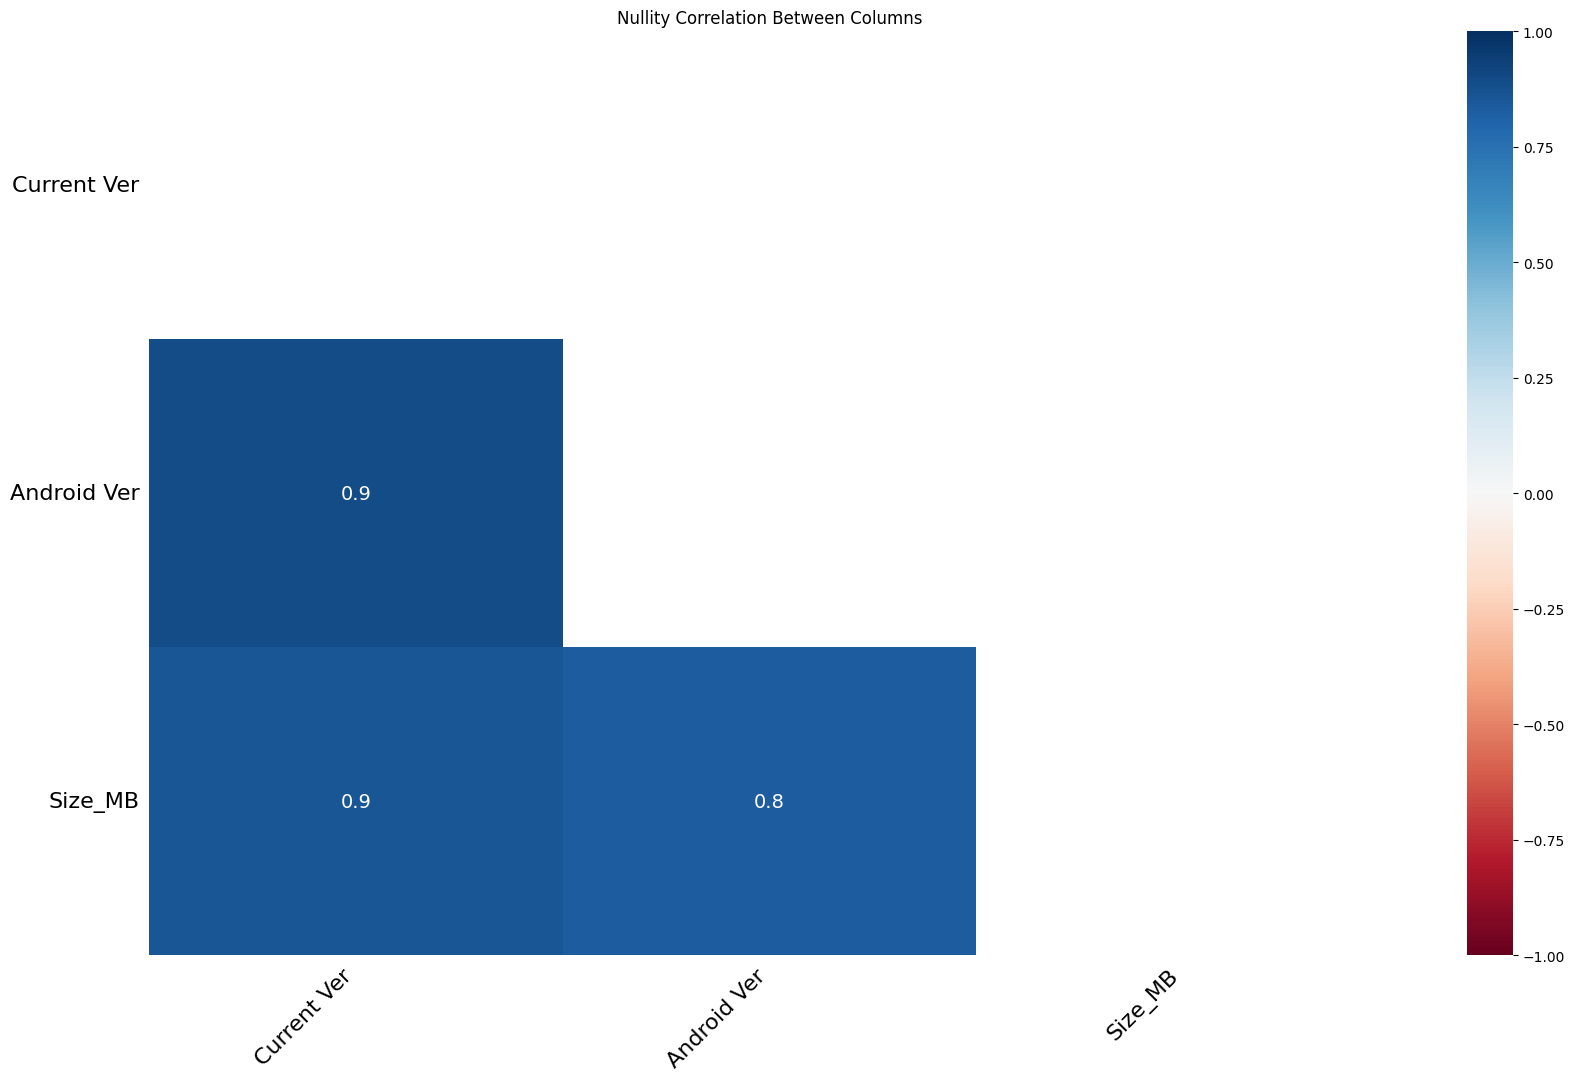

In [39]:
# Nullity correlation across all columns with missing data
msno.heatmap(df)
plt.title("Nullity Correlation Between Columns")
plt.show()

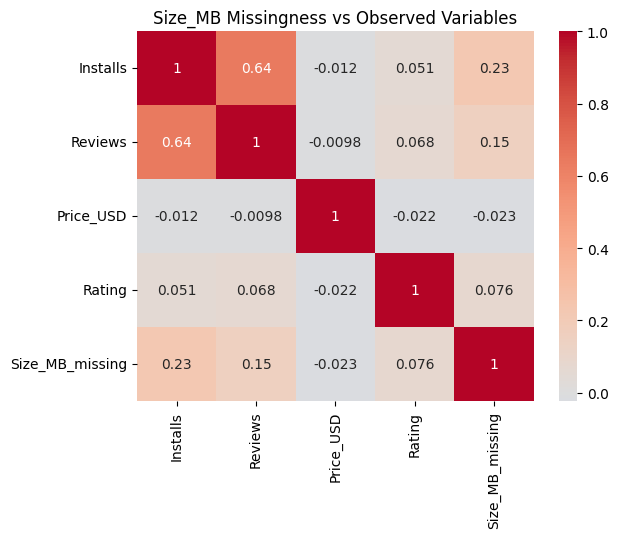

Price_USD   -0.022901
Rating       0.075520
Reviews      0.151623
Installs     0.225777
Name: Size_MB_missing, dtype: float64


In [40]:
# Does Size_MB's missingness correlate with observed numeric variables?
check_df = df[['Installs', 'Reviews', 'Price_USD', 'Rating']].copy()
check_df['Size_MB_missing'] = df['Size_MB'].isna().astype(int)

corr = check_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Size_MB Missingness vs Observed Variables")
plt.show()

print(corr['Size_MB_missing'].drop('Size_MB_missing').sort_values())

Little's test rejects MCAR, and the heatmaps show `Size_MB`'s missingness correlates with `Installs` (and with `Current Ver`/`Android Ver` missingness) not with `Rating`. Missingness is explainable by an *observed* variable, which is the definition of **MAR**.

Unlike standard correlation, where 0.20 indicates a weak relationship, a non-zero correlation with a missingness indicator suggests missingness depends on an observed variable, providing evidence against MCAR and supporting MAR.

Domain match: every missing value came from "Varies with device," a label used mainly by large, high-install apps shipping device-specific builds.

`Size_MB` is a predictor, and its missingness concentrates in the highest-install apps, exactly the apps most relevant to the research question. Dropping them would bias the size-installs relationship. **Impute** with the category median, and keep a `Size_Varies` flag so the "varies with device" signal isn't lost.

In [41]:
df['Size_Varies'] = df['Size_MB'].isna()

category_median_size = df.groupby('Category')['Size_MB'].transform('median')
overall_median_size = df['Size_MB'].median()

df['Size_MB'] = df['Size_MB'].fillna(category_median_size)
df['Size_MB'] = df['Size_MB'].fillna(overall_median_size)

print(f"Remaining nulls in Size_MB: {df['Size_MB'].isna().sum()}")
print(f"Apps flagged Size_Varies: {df['Size_Varies'].sum()}")

Remaining nulls in Size_MB: 0
Apps flagged Size_Varies: 1637


##### 4.4) Analyze missingness of Categorical/Text Columns (Type, Current Ver, Android Ver)

`Type` has only 1 missing row. For `Current Ver`/`Android Ver`, we test association with the `Size_Varies` flag from 5.1 (same "varies with device" text).

In [42]:
# Type: inspect the single missing row
print("Row(s) missing Type:")
print(df[df['Type'].isna()][['App', 'Category', 'Price_USD']])

Row(s) missing Type:
Empty DataFrame
Columns: [App, Category, Price_USD]
Index: []


In [43]:
# Current Ver / Android Ver: quantify missingness
cur_missing = df['Current Ver'].isna()
and_missing = df['Android Ver'].isna()
print(f"\nCurrent Ver missing: {cur_missing.sum()} ({cur_missing.mean()*100:.2f}%)")
print(f"Android Ver missing: {and_missing.sum()} ({and_missing.mean()*100:.2f}%)")


Current Ver missing: 1419 (15.15%)
Android Ver missing: 1321 (14.10%)


####  4.4.1) Chi-square test

In [44]:
# Chi-square test: is Current Ver missingness associated with Size_Varies?
contingency = pd.crosstab(df['Size_Varies'], cur_missing)
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print("\nCrosstab: Size_Varies vs Current Ver missing")
print(contingency)
print(f"\nChi-square p-value: {p_chi2:.4e}")


Crosstab: Size_Varies vs Current Ver missing
Current Ver  False  True 
Size_Varies              
False         7652     77
True           295   1342

Chi-square p-value: 0.0000e+00


`Type` — a single missing row, no pattern to test: **MCAR**, likely a one-off data-entry gap.

`Current Ver`/`Android Ver` — the chi-square test rejects independence from `Size_Varies`: missingness is explained by the same observed condition (device-adaptive delivery) as `Size_MB`. Same mechanism as 4.3: **MAR**.

`Type` encodes the pricing model, part of our research question: drop the 1 row rather than guess it. `Current Ver`/`Android Ver` are outside the research question's scope, so we keep the rows and impute with an explicit `"unknown"` placeholder instead of dropping ~13% of the data.

In [45]:
df = df.dropna(subset=['Type']).copy()

### 4.4.2) Correction: Version Missing Values

The earlier cleaning step incorrectly converted `"Varies with device"` to `NaN` in `Current Ver` and `Android Ver`. Unlike `Size_MB`, this is meaningful information for version columns. We therefore restore `"Varies with device"` to preserve the original information.

In [46]:
df['Current Ver'] = df['Current Ver'].fillna('varies with device')
df['Android Ver'] = df['Android Ver'].fillna('varies with device')

print(df[['Type', 'Current Ver', 'Android Ver']].isnull().sum())
print(f"\nFinal dataset shape after Section 5: {df.shape}")

Type           0
Current Ver    0
Android Ver    0
dtype: int64

Final dataset shape after Section 5: (9366, 14)


In [47]:
df[df["Size_Varies"] == True]

,App,Category,Rating,Reviews,Installs,Type,Price_USD,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Size_Varies
37,floor plan creator,art_and_design,4.1,36639,5000000,free,0.0,everyone,art & design,2018-07-14,varies with device,2.3.3 and up,9.20,True
42,textgram - write on photos,art_and_design,4.4,295221,10000000,free,0.0,everyone,art & design,2018-07-30,varies with device,varies with device,9.20,True
52,used cars and trucks for sale,auto_and_vehicles,4.6,17057,1000000,free,0.0,everyone,auto & vehicles,2018-07-30,varies with device,varies with device,16.00,True
67,ulysse speedometer,auto_and_vehicles,4.3,40211,5000000,free,0.0,everyone,auto & vehicles,2018-07-30,varies with device,varies with device,16.00,True
68,repuve,auto_and_vehicles,3.9,356,100000,free,0.0,everyone,auto & vehicles,2018-05-25,varies with device,varies with device,16.00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,my earthquake alerts - us & worldwide earthquakes,weather,4.4,3471,100000,free,0.0,everyone,weather,2018-07-24,varies with device,varies with device,9.20,True
10725,posta app,maps_and_navigation,3.6,8,1000,free,0.0,everyone,maps & navigation,2017-09-27,varies with device,4.4 and up,10.00,True
10765,chat for strangers - video chat,social,3.4,622,100000,free,0.0,mature 17+,social,2018-05-23,varies with device,varies with device,9.90,True
10826,frim: get new friends on local chat rooms,social,4.0,88486,5000000,free,0.0,mature 17+,social,2018-03-23,varies with device,varies with device,9.90,True


#### 4.4.3) Drop columns not useful.

In [48]:
df = df.drop(columns=["Size_Varies"])

In [49]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Installs          0
Type              0
Price_USD         0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64

In [50]:
df.shape

(9366, 13)

### 5) Duplicate App Records

Repeated `App` names don't all mean the same thing here. This dataset was scraped from Play Store *category listing pages*, so one app can legitimately show up under more than one `Category` — that's not duplication, that's two real observations for a category-level pricing analysis. True duplication is when the *same* app, in the *same* category, was simply scraped more than once. We handle these two cases separately instead of collapsing everything on `App` alone.

#### 5.1) Diagnostic — What's actually driving the repeats?

For every `App` name that appears more than once, we check how many distinct `Category` values it spans. Names confined to one category are likely true re-scrapes. Names spanning multiple categories are likely valid cross-listings that should be kept.

In [51]:
name_dupes = df[df.duplicated(subset='App', keep=False)].sort_values('App')

cat_spread = name_dupes.groupby('App')['Category'].nunique()

print("App-name dupes spanning >1 category:", (cat_spread > 1).sum())
print("App-name dupes confined to 1 category:", (cat_spread == 1).sum())

App-name dupes spanning >1 category: 88
App-name dupes confined to 1 category: 711


Most repeated names are confined to a single category was true duplication, not lost data. But a meaningful group (the multi-category names) would have been wrongly deleted by `drop_duplicates(subset='App')`, those are handled by keying on `App` + `Category` below, instead of `App` alone.

#### 5.2) Drop Exact Full-Row Duplicates

Rows identical across *every* column are clear, the same scrape record appearing twice, not two different listings. These are removed first, before any name- or category-based logic is applied.

In [53]:
df = df.drop_duplicates(keep='first')  # full row, not subset=['App']
print(f"Shape after removing exact duplicate rows: {df.shape}")

Shape after removing exact duplicate rows: (8892, 13)


#### 5.3) Deduplicate on (App, Category), Keep the Most Recent Snapshot

Keying on `App` + `Category` instead of `App` alone keeps every legitimate category listing intact (from 5.1), while still collapsing true repeat-scrapes of the same app in the same category down to one row.

For each `(App, Category)` group, we keep the row with the most recent `Last Updated` date, since that best reflects the app's current state, what we actually care about for the pricing/rating analysis. `Reviews` (highest) is used only as a tie-breaker when `Last Updated` is identical.

In [54]:
df = (
    df.sort_values(['Last Updated', 'Reviews'], ascending=[False, False])
      .drop_duplicates(subset=['App', 'Category'], keep='first')
)
print(f"Shape after App+Category deduplication: {df.shape}")

Shape after App+Category deduplication: (8270, 13)


#### 5.4) Residual Same-Name Duplicates — Documented Limitation

Any `App` name still repeated at this point also shares the same `Category`, and was already resolved to one row by the most-recent-snapshot rule above — so it's not extra duplication, it's a name that happens to recur across the resolved rows for a different category-independent reason. We do a quick sanity check for how many such names remain.

In [55]:
residual = df[df.duplicated(subset='App', keep=False)]
print(f"App names still repeated after dedup: {residual['App'].nunique()}")
residual[['App','Category','Reviews','Price_USD','Rating']].sort_values('App').head(10)

App names still repeated after dedup: 88


,App,Category,Reviews,Price_USD,Rating
1871,8 ball pool,game,14201891,0.0,4.5
3953,8 ball pool,sports,14184910,0.0,4.5
920,a&e - watch full episodes of tv shows,entertainment,29706,0.0,4.0
4991,a&e - watch full episodes of tv shows,family,29708,0.0,4.0
1843,angry birds 2,game,3883589,0.0,4.6
4864,angry birds 2,family,3881752,0.0,4.6
8297,babbel – learn languages,family,267787,0.0,4.3
717,babbel – learn languages,education,266948,0.0,4.3
1687,barbie™ fashion closet,game,68057,0.0,4.1
2045,barbie™ fashion closet,family,68286,0.0,4.1


This dataset has no developer ID or unique app identifier, so we can't *prove* two same-name rows are the same app rather than a rare coincidental match on every field. We rely on the assumption that same name + same/adjacent category + similar stats means the same app — a documented limitation of this analysis, not a certainty.

In [56]:
df.shape

(8270, 13)

In [57]:
df.shape

(8270, 13)

### 6) Statistical Reliability Filter — Reviews ≥ 500

Apps with fewer than 500 reviews produce statistically unreliable ratings. A small handful of enthusiastic early adopters can push a premium app's average to 4.8★, making it indistinguishable from a genuinely well-rated product that has been validated at scale. To assess *price tolerance* reliably (i.e., whether a category's users accept premium pricing and still rate the app highly), we need ratings that reflect a statistically meaningful sample. Apps below the 500-review threshold are dropped as noise, not signal.

In [58]:
df = df[df['Reviews'] >= 500].copy()

In [59]:
df.shape

(5333, 13)

In [60]:
print("Shape BEFORE cleaning: (10841, 13)")
print(f"Shape AFTER cleaning:  {df.shape}")
df.info()
display(df.describe())

Shape BEFORE cleaning: (10841, 13)
Shape AFTER cleaning:  (5333, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 5333 entries, 10408 to 7479
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             5333 non-null   object        
 1   Category        5333 non-null   object        
 2   Rating          5333 non-null   float64       
 3   Reviews         5333 non-null   Int64         
 4   Installs        5333 non-null   Int64         
 5   Type            5333 non-null   object        
 6   Price_USD       5333 non-null   float64       
 7   Content Rating  5333 non-null   object        
 8   Genres          5333 non-null   object        
 9   Last Updated    5333 non-null   datetime64[ns]
 10  Current Ver     5333 non-null   object        
 11  Android Ver     5333 non-null   object        
 12  Size_MB         5333 non-null   float64       
dtypes: Int64(2), datetime64[ns](1), float64(

,Rating,Reviews,Installs,Price_USD,Last Updated,Size_MB
count,5333.000000,5333.0,5333.0,5333.000000,5333,5333.000000
mean,4.234015,433882.301706,14955117.944872,0.486096,2018-01-04 03:48:26.056628736,24.206273
min,1.700000,500.0,1000.0,0.000000,2010-05-21 00:00:00,0.010742
25%,4.100000,3834.0,100000.0,0.000000,2017-12-29 00:00:00,7.300000
50%,4.300000,23641.0,1000000.0,0.000000,2018-06-21 00:00:00,16.000000
75%,4.500000,129272.0,10000000.0,0.000000,2018-07-26 00:00:00,35.000000
max,4.900000,78158306.0,1000000000.0,399.990000,2018-08-08 00:00:00,100.000000
std,0.376771,2597805.095179,74034326.898377,11.007726,NaN,22.935562
